In [1]:
# imports
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

%cd /home/varshini/uc_analyses/
import utils, loops_txn, matchmaker_functions
%cd /home/varshini/LoopCall_Analysis_Scripts

import ast
from sklearn import feature_selection
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})

plt.rcParams["legend.frameon"] = False

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/matchmaker_scores/'
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v1/figure5"

In [3]:
# load MM datasets

type_use= 'enhancernotpromoternotctcf'
peak_use = 'erythroid_tf_acrs_all'

phases = ['AAVS1_C2_G1', 'NIPBL_C2_G1',
          'AAVS1_C3_G1',  'NIPBL_C3_G1']

dists = [25000, 50000, 100000, 200000]
dist= dists[2]

control_phase = phases[2]
test_phase = phases[3]


LIST_COLS = ['crosser_loop_scores', 'crosser_loop_classes',
            'ss_loop_scores', 'ss_loop_classes']
diff_thresh = 10000

In [4]:
# multiple phases
nametag = f"{peak_use}_{type_use}"
nametag=type_use
match_scores = matchmaker_functions.load_matchmaker_scores_phase(datapath, phases, nametag = nametag, list_cols = LIST_COLS,
                                            dist=dist, difference_threshold=diff_thresh,triangle_score_cols=['triangle_score_P1','triangle_score_P2', 'triangle_score_P3', 'triangle_score_P4']).dropna(subset='triangle_score_P1')
match_scores_control = matchmaker_functions.load_matchmaker_scores_phase(datapath, phases, nametag = f"shuffled_sites", list_cols = LIST_COLS,
                                            dist=dist, difference_threshold=diff_thresh,triangle_score_cols=['triangle_score_P1','triangle_score_P2', 'triangle_score_P3', 'triangle_score_P4']).dropna(subset='triangle_score_P1')

In [5]:
og_mm = pd.read_csv(f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/{nametag}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed",
                   sep="\t")
og_mm = og_mm[['chr', 'coord', 'quant']]

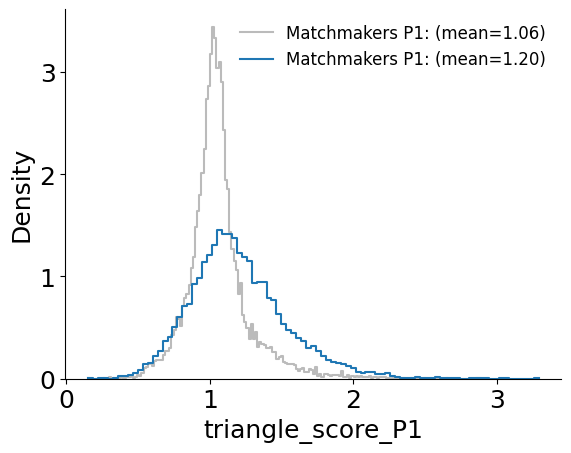

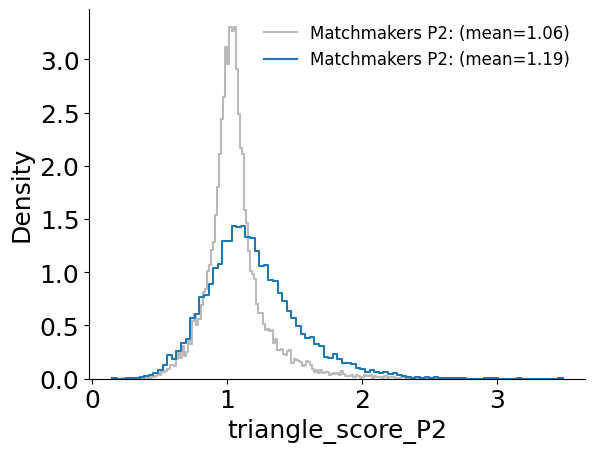

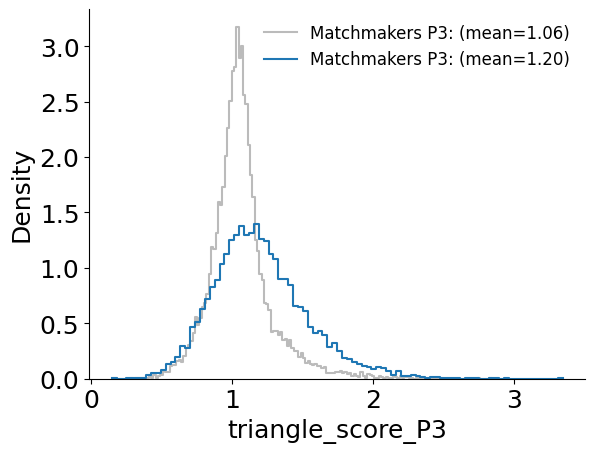

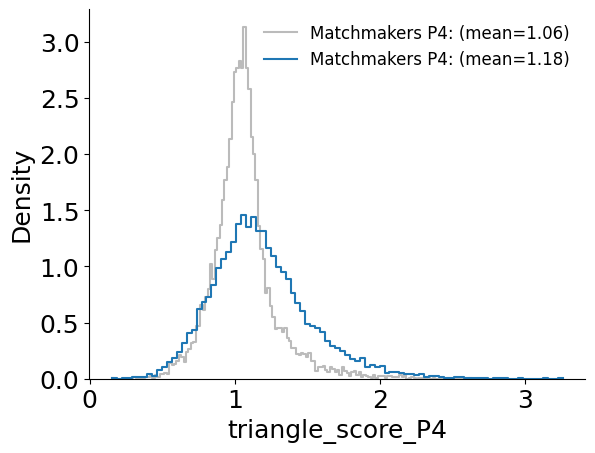

In [6]:
# cluster according to [what?]

# histogram of triangle score vs control
for i in range(1, len(phases)+1):
    plt.figure()

    score_col_phase = f"triangle_score_P{i}"
   
    sns.histplot(match_scores_control[score_col_phase], common_norm=False, stat='density', 
                         fill=False, element="step", color="#BBBBBB", label=f"Matchmakers P{i}: (mean={np.mean(match_scores_control[score_col_phase]):.2f})")
    sns.histplot(match_scores[score_col_phase], common_norm=False, stat='density', 
                         fill=False, element="step", label=f"Matchmakers P{i}: (mean={np.mean(match_scores[score_col_phase]):.2f})")
    plt.legend(fontsize=12)
    plt.show()

                triangle_score_P1  triangle_score_P2  triangle_score_P3  \
locus                                                                     
chr1:1024193             1.424604           1.274135           1.306836   
chr2:30325893            1.453632           1.376439           1.413544   
chr2:30303500            1.562030           1.554526           1.547998   
chr2:30292336            1.568730           1.641819           1.532300   
chr2:30266232            1.249975           1.425521           1.269366   
...                           ...                ...                ...   
chr3:48501062            1.891931           1.778538           1.760243   
chr9:37995122            1.810543           1.869050           1.787016   
chr6:13675857            1.764853           1.686929           1.775688   
chr16:129472             2.506972           2.318400           2.516366   
chr14:75229883           2.232985           2.177656           2.180686   

                triangle

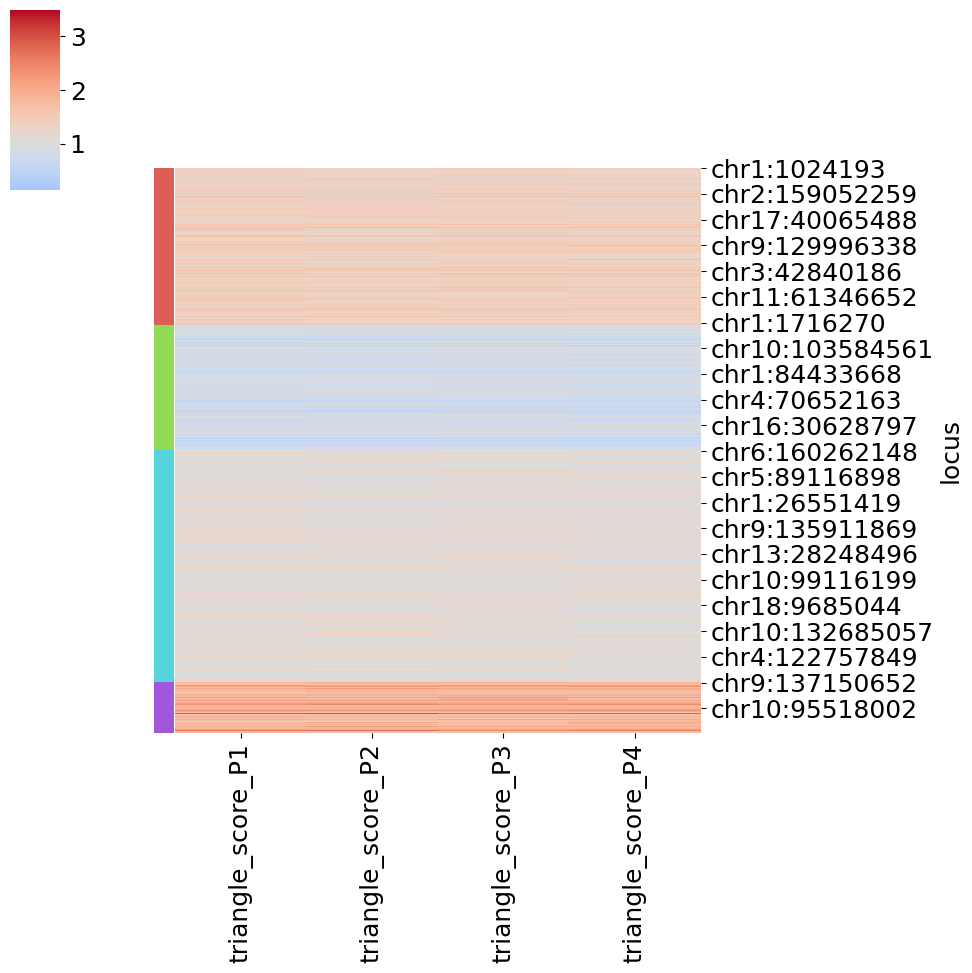

In [7]:
n_quant = 4

cleaned_scores = match_scores[[f"triangle_score_P{i}" for i in (range(1, len(phases)+1))]].dropna()
cleaned_scores = cleaned_scores[(cleaned_scores != 0).all(axis=1)]

grp = matchmaker_functions.do_kmeans(cleaned_scores, 4, rand=42)
cleaned_scores = matchmaker_functions.plot_clusters(cleaned_scores, grp)
inds = cleaned_scores.groupby('g').agg('triangle_score_P1').mean().sort_values().index.tolist()
ind_dict = dict(zip(inds, np.arange(4)))
cleaned_scores['quant'] = cleaned_scores['g'].map(ind_dict)
cleaned_scores.drop('g', inplace=True, axis=1)

In [8]:
match_scores_grouped = match_scores.merge(cleaned_scores['quant'], how='inner', left_index=True, right_index=True)
#match_scores_grouped = match_scores_grouped.merge(og_mm, on=['chr', 'coord'],  how='left', suffixes=('','_diff'))

In [9]:
max_diff = 10_000
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

out = []

for chrom in chrom_order:

    left = (
        match_scores_grouped[match_scores_grouped['chr'] == chrom]
        .sort_values('coord')
    )

    right = (
        og_mm[og_mm['chr'] == chrom]
        .sort_values('coord')
    )

    if len(left) == 0 or len(right) == 0:
        continue

    merged_chr = pd.merge_asof(
        left,
        right,
        on='coord',
        direction='nearest',
        tolerance=max_diff,
        suffixes=('', '_diff')
    )

    out.append(merged_chr)

merged = pd.concat(out, ignore_index=True)

In [11]:
nametag

'enhancernotpromoternotctcf'

In [12]:
savedir=f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/nipbl_{nametag}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed"
#merged.to_csv(savedir, sep="\t", index=False)

In [24]:
## merging analyses 

test_phase = 'P4'
control_phase = 'P3'
merged_df = matchmaker_functions.merged_attrs(merged[(merged['quant_diff']==3)|(merged['quant_diff']==2)], test_phase, control_phase)
merged_df_control = matchmaker_functions.merged_attrs(match_scores_control, test_phase, control_phase)



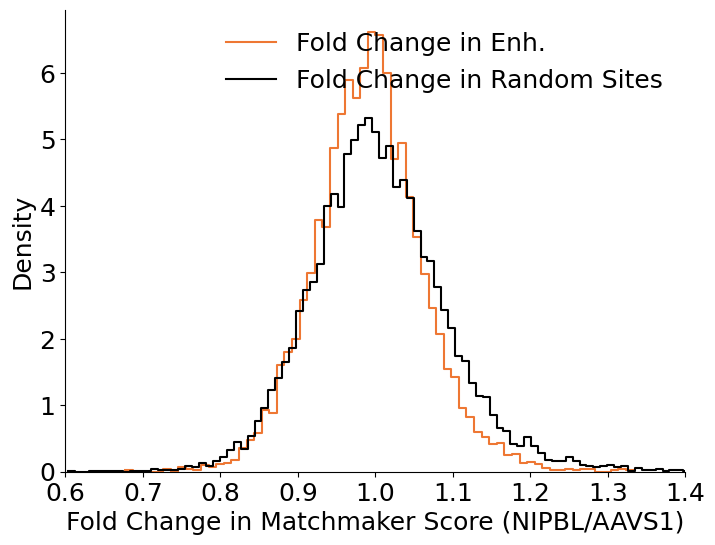

In [25]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v2/supp14"
if not os.path.exists(savedir):
    os.mkdir(savedir)

plt.figure(figsize=(8,6))
sns.histplot(merged_df['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='#ee7733',label='Fold Change in Enh.')
sns.histplot(merged_df_control['triangle_fc'], stat='density', common_norm=False,
                     fill=False, element="step", color='k', label='Fold Change in Random Sites')
plt.xlim([0.6, 1.4])
plt.xlabel('Fold Change in Matchmaker Score (NIPBL/AAVS1)')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(savedir, f"MM_NIPBL_{test_phase}_vs_{control_phase}.svg"))


In [22]:
clean_x = merged_df.dropna(subset=['triangle_fc', 'crosser_fc'])['triangle_fc'].values.reshape(-1, 1)
clean_y = merged_df.dropna(subset=['triangle_fc', 'crosser_fc'])['crosser_fc'].values.reshape(-1, 1)
reg_crosser = LinearRegression().fit(clean_x, 
                                     clean_y)
interc = reg_crosser.intercept_
coef = reg_crosser.coef_
pred_y = reg_crosser.predict(clean_x)


clean_x_ss = merged_df.dropna(subset=['triangle_fc', 'ss_fc'])['triangle_fc'].values.reshape(-1, 1)
clean_y_ss = merged_df.dropna(subset=['triangle_fc', 'ss_fc'])['ss_fc'].values.reshape(-1, 1)
reg_ss = LinearRegression().fit(clean_x_ss, 
                                    clean_y_ss )
interc_ss = reg_ss.intercept_
coef_ss = reg_ss.coef_

pred_y_ss = reg_ss.predict(clean_x_ss)

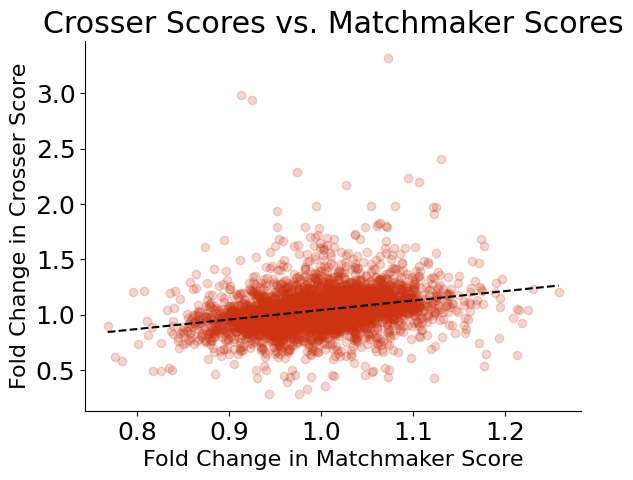

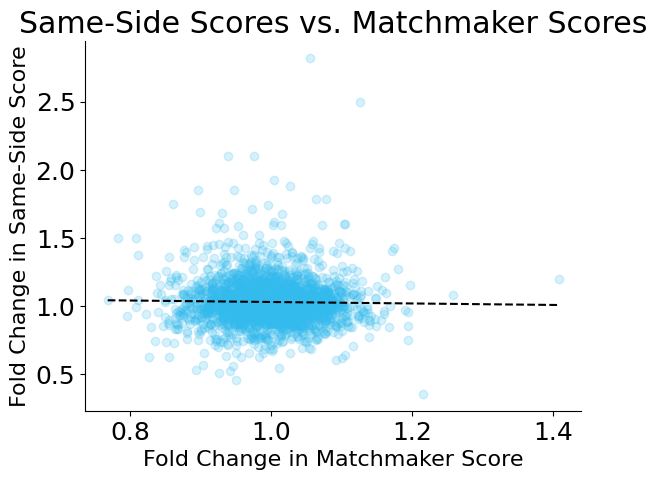

In [23]:

# triangle fc vs ss 
plt.scatter(merged_df['triangle_fc'], merged_df['crosser_fc'], alpha=0.2, color='#CC3311')
plt.xlabel('Fold Change in Matchmaker Score', fontsize=16)
plt.ylabel('Fold Change in Crosser Score', fontsize=16)
plt.plot(clean_x, pred_y, linestyle='--', color='k')
#plt.ylim([0.4, 1.5])
#plt.xlim([0.8, 1.2])
plt.title('Crosser Scores vs. Matchmaker Scores')
#plt.savefig(os.path.join(savedir, 'crosser_match_fc_corr.svg'))
plt.show()

plt.scatter(merged_df['triangle_fc'], merged_df['ss_fc'], alpha=0.2, color='#33BBEE')
plt.plot(clean_x_ss, pred_y_ss, linestyle='--', color='k')

plt.xlabel('Fold Change in Matchmaker Score',fontsize=16)
plt.ylabel('Fold Change in Same-Side Score', fontsize=16)
plt.title('Same-Side Scores vs. Matchmaker Scores')
#plt.ylim([0.5, 1.5])
#plt.ylim([0.7, 1.5])
#plt.savefig(os.path.join(savedir, 'ss_match_fc_corr.svg'))
plt.show()

NameError: name 'phases' is not defined